In [1]:
!pip install py_vncorenlp

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.3 MB/s eta 0:00:0000:01
  Created wheel for py_vncorenlp: filename=py_vncorenlp-0.1.4-py3-none-any.whl size=4304 sha256=fa755cd32a032244a8f4b5d1f1577971be985b70226c2f516ae5304319098279
  Stored in directory: /root/.cache/pip/wheels/db/e5/ff/f4a1b4ece36e8582db1ca71150a34e987e65df50c35974e9bb
Successfully built py_vncorenlp


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import py_vncorenlp
import torch

In [3]:
py_vncorenlp.download_model(save_dir='/kaggle/working')

--2026-02-20 04:48:59--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412703 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.2.jar’

     0K .......... .......... .......... .......... ..........  0% 6.48M 4s
    50K .......... .......... .......... .......... ..........  0% 7.54M 4s
   100K .......... .......... .......... .......... ..........  0% 39.3M 3s
   150K .......... .......... .......... .......... ..........  0% 42.7M 2s
   200K .......... .......... .......... .......... ..........  0% 43.7M 2s
   250K .......... .......... .......... .......... ..........  1% 11.2M 2s
   300K .......... .......... .......... .......... ..........  1% 86.0M 2s
   350K ..

In [4]:
# Load the word and sentence segmentation component
rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/kaggle/working')

text = "Ông Nguyễn Khắc Chúc  đang làm việc tại Đại học Quốc gia Hà Nội. Bà Lan, vợ ông Chúc, cũng làm việc tại đây."

output = rdrsegmenter.word_segment(text)

print(output)
# ['Ông Nguyễn_Khắc_Chúc đang làm_việc tại Đại_học Quốc_gia Hà_Nội .', 'Bà Lan , vợ ông Chúc , cũng làm_việc tại đây .']

2026-02-20 04:49:07 INFO  WordSegmenter:24 - Loading Word Segmentation model
['Ông Nguyễn_Khắc_Chúc đang làm_việc tại Đại_học Quốc_gia Hà_Nội .', 'Bà Lan , vợ ông Chúc , cũng làm_việc tại đây .']


In [5]:
# segment laws in corpus

with open("/kaggle/input/traindata-retrieval/legal_corpus.json", "r", encoding="utf-8") as f:
    data = json.load(f)

for set_raws in data:
    for raw in set_raws['content']:
        output = rdrsegmenter.word_segment(raw['content_Article'])
        raw['content_Article'] = " ".join(output)

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
chunked_data = []
overlap = 64
max_chunked = 256

from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer, 
    chunk_size=max_chunked, 
    chunk_overlap=overlap
)

for set_raws in data:
    for raw in set_raws['content']:
        chunked_Article = text_splitter.split_text(raw['content_Article'])
        for idx, chunked in enumerate(chunked_Article):
            token_count = len(tokenizer.encode(chunked))
            chunked_data.append({
                "aid": raw["aid"],
                "chunk_id": str(raw['aid']) + "_" + str(idx),
                "content_Article": chunked
            })

In [18]:
with open(f"chunked_corpus.json", "w", encoding="utf-8") as f:
        json.dump(chunked_data, f, ensure_ascii=False)

In [8]:
list_all_size = []
for set_raws in data:
    for raw in set_raws['content']:
        list_all_size.append(len(tokenizer.encode(raw['content_Article'])))

In [9]:
len(list_all_size)

59636

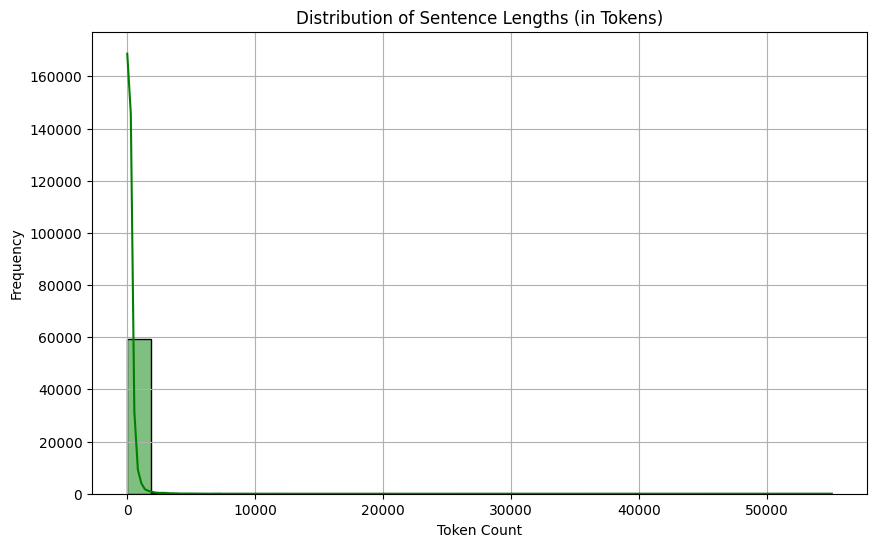

Summary Statistics:
count    59636.000000
mean       247.359464
std        510.767958
min          2.000000
25%         79.000000
50%        149.000000
75%        277.000000
max      55065.000000
dtype: float64
Median: 149.0
Mode: 45


In [ ]:
sentence_lengths = list_all_size

lengths_series = pd.Series(sentence_lengths)

plt.figure(figsize=(10, 6))
sns.histplot(lengths_series, bins=30, kde=True, color='green')
plt.title('Distribution of Sentence Lengths (in Tokens)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print("Summary Statistics:")
print(lengths_series.describe())
print(f"Median: {lengths_series.median()}")
print(f"Mode: {lengths_series.mode().iloc[0]}")

In [11]:
with open("/kaggle/input/traindata-retrieval/train.json", "r", encoding = "utf-8") as f:
    train_data = json.load(f)

# segment question in train data
for q in train_data:
    output = rdrsegmenter.word_segment(q['question'])
    q['question'] = " ".join(output)
    q['tokenized_question'] = torch.tensor([tokenizer.encode(q['question'])])

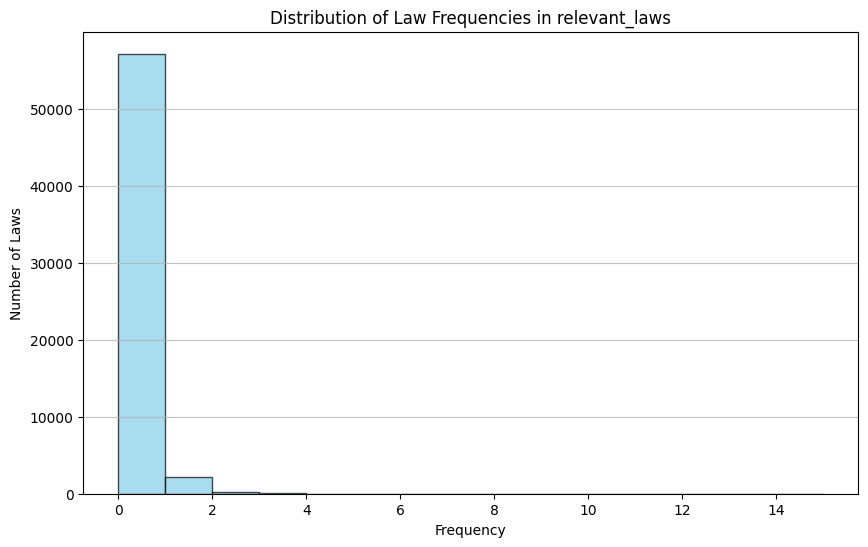

Total laws: 59636
Laws with frequency > 0: 2505
Max frequency: 14
Min frequency (non-zero): 1
Mean frequency (non-zero): 1.173253493013972


In [12]:
law_freq = {i: 0 for i in range(59636)}

for item in train_data:
    for law_id in item['relevant_laws']:
        if law_id in law_freq:
            law_freq[law_id] += 1

freq_values = list(law_freq.values())

plt.figure(figsize=(10, 6))
plt.hist(freq_values, bins=range(0, max(freq_values)+2), color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Law Frequencies in relevant_laws')
plt.xlabel('Frequency')
plt.ylabel('Number of Laws')
plt.grid(axis='y', alpha=0.75)
plt.show()

non_zero_freqs = [f for f in freq_values if f > 0]
print(f"Total laws: {len(freq_values)}")
print(f"Laws with frequency > 0: {len(non_zero_freqs)}")
print(f"Max frequency: {max(freq_values)}")
print(f"Min frequency (non-zero): {min(non_zero_freqs) if non_zero_freqs else 0}")
print(f"Mean frequency (non-zero): {np.mean(non_zero_freqs) if non_zero_freqs else 0}")

In [13]:
def assess_len_query(data):
    len_questions = []
    for q in data:
        len_questions.append(q['tokenized_question'].size(1))
    sentence_lengths = len_questions
    
    lengths_series = pd.Series(sentence_lengths)
    
    plt.figure(figsize=(10, 6))
    sns.histplot(lengths_series, bins=30, kde=True, color='green')
    plt.title('Distribution of Sentence Lengths (in Tokens)')
    plt.xlabel('Token Count')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    print("Summary Statistics:")
    print(lengths_series.describe())
    print(f"Median: {lengths_series.median()}")
    print(f"Mode: {lengths_series.mode().iloc[0]}")
    

query length in train data:


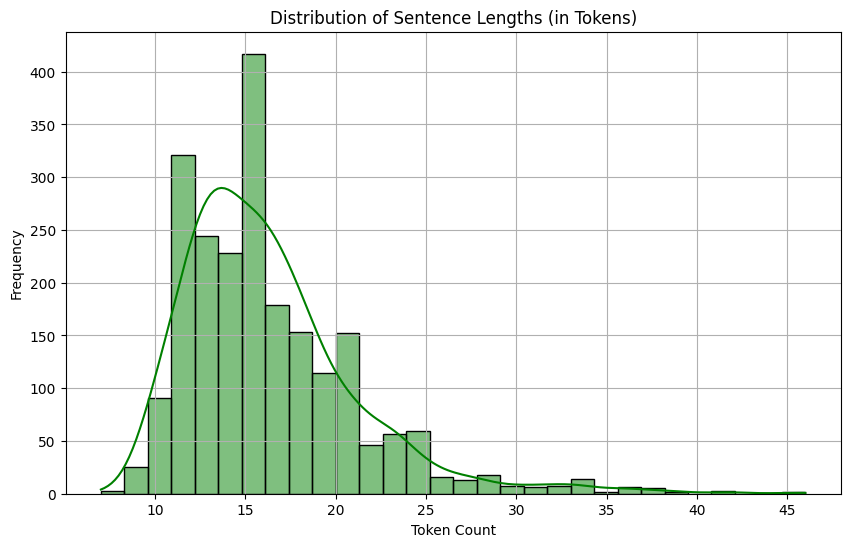

Summary Statistics:
count    2190.000000
mean       16.294977
std         4.898860
min         7.000000
25%        13.000000
50%        15.000000
75%        18.000000
max        46.000000
dtype: float64
Median: 15.0
Mode: 13


In [14]:
print("query length in train data:")
assess_len_query(train_data)